# Notebook 2 — Nested CV, Modèles & Model Card

---
## 0. Imports & configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Imports OK')

Imports OK


---
## 1. Chargement du dataset nettoyé

In [3]:
df = pd.read_csv('../../data/concrete_clean.csv')

X = df.drop(columns=['strength'])
y = df['strength']

print(f'Observations : {len(df)}')
print(f'Features     : {X.shape[1]} → {list(X.columns)}')
print(f'Target       : strength (MPa) — moyenne {y.mean():.2f}, std {y.std():.2f}')

Observations : 1005
Features     : 8 → ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age']
Target       : strength (MPa) — moyenne 35.25, std 16.28


---
## 2. Nested Cross-Validation — Configuration

In [4]:
# Boucle interne : tuning des hyperparamètres
# 5 folds car dataset ~1000 observations (règle : 5-CV standard pour 200 ≤ n ≤ 10^5)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Boucle externe : estimation non biaisée de la GE
# random_state DIFFÉRENT pour éviter tout chevauchement structurel avec l'inner
outer_cv = KFold(n_splits=5, shuffle=True, random_state=0)

SCORING_INNER = 'neg_mean_squared_error'   # utilisé dans GridSearchCV
N_JOBS = -1                                 # parallélisation sur tous les CPUs

print('Inner CV :', inner_cv)
print('Outer CV :', outer_cv)

# Helper pour calculer RMSE et R² depuis les scores outer (neg_MSE → RMSE)
def compute_metrics(neg_mse_scores, y_true=None, model_name=''):
    mse_scores = -neg_mse_scores
    rmse_scores = np.sqrt(mse_scores)
    print(f'\n=== {model_name} ===')
    print(f'RMSE par fold : {np.round(rmse_scores, 3)}')
    print(f'RMSE moyen    : {rmse_scores.mean():.3f} MPa  (±{rmse_scores.std():.3f})')
    return rmse_scores

Inner CV : KFold(n_splits=5, random_state=42, shuffle=True)
Outer CV : KFold(n_splits=5, random_state=0, shuffle=True)


---
## 3. Modèle 1 — Ridge Regression

In [5]:
# --- PIPELINE RIDGE ---
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),   # preprocessing encapsulé → zéro leakage
    ('model', Ridge())
])

# Grille d'hyperparamètres
# Préfixe 'model__' obligatoire car on passe par le Pipeline
param_grid_ridge = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
# Total : 7 valeurs × 5 folds inner × 5 folds outer = 175 entraînements

# INNER LOOP : GridSearchCV tune les hyperparamètres
search_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid_ridge,
    cv=inner_cv,
    scoring=SCORING_INNER,
    refit=True,       # ré-entraîne le meilleur modèle sur tout le fold train externe
    n_jobs=N_JOBS
)

# OUTER LOOP : cross_val_score évalue la GE non biaisée
print('Entraînement Ridge en cours...')
t0 = time.time()

scores_ridge = cross_val_score(
    estimator=search_ridge,
    X=X, y=y,
    cv=outer_cv,
    scoring=SCORING_INNER,  # neg_MSE → on convertira en RMSE
    n_jobs=N_JOBS
)

elapsed = time.time() - t0
print(f'Terminé en {elapsed:.1f}s')

rmse_ridge = compute_metrics(scores_ridge, model_name='Ridge Regression')

Entraînement Ridge en cours...
Terminé en 2.6s

=== Ridge Regression ===
RMSE par fold : [ 9.874 10.524 11.174 10.086 10.267]
RMSE moyen    : 10.385 MPa  (±0.449)


In [6]:
# Calcul du R² pour Ridge via cross_val_score avec scoring='r2'
r2_ridge = cross_val_score(
    estimator=search_ridge,
    X=X, y=y,
    cv=outer_cv,
    scoring='r2',
    n_jobs=N_JOBS
)
print(f'R² moyen Ridge : {r2_ridge.mean():.3f} (±{r2_ridge.std():.3f})')

R² moyen Ridge : 0.590 (±0.031)


---
## 4. Modèle 2 — Random Forest Regressor

In [7]:
# --- PIPELINE RANDOM FOREST ---
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),   # pas strictement nécessaire pour RF, mais pipeline cohérent
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2]
}
# Total : 3 × 4 × 3 × 2 = 72 combinaisons × 5 folds inner × 5 folds outer = 1 800 entraînements

search_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=inner_cv,
    scoring=SCORING_INNER,
    refit=True,
    n_jobs=N_JOBS
)

print('Entraînement Random Forest en cours...')
t0 = time.time()

scores_rf = cross_val_score(
    estimator=search_rf,
    X=X, y=y,
    cv=outer_cv,
    scoring=SCORING_INNER,
    n_jobs=N_JOBS
)

elapsed = time.time() - t0
print(f'Terminé en {elapsed:.1f}s')

rmse_rf = compute_metrics(scores_rf, model_name='Random Forest')

Entraînement Random Forest en cours...
Terminé en 89.5s

=== Random Forest ===
RMSE par fold : [4.808 5.066 4.642 5.495 4.666]
RMSE moyen    : 4.935 MPa  (±0.318)


In [8]:
r2_rf = cross_val_score(
    estimator=search_rf,
    X=X, y=y,
    cv=outer_cv,
    scoring='r2',
    n_jobs=N_JOBS
)
print(f'R² moyen RF : {r2_rf.mean():.3f} (±{r2_rf.std():.3f})')

R² moyen RF : 0.907 (±0.014)


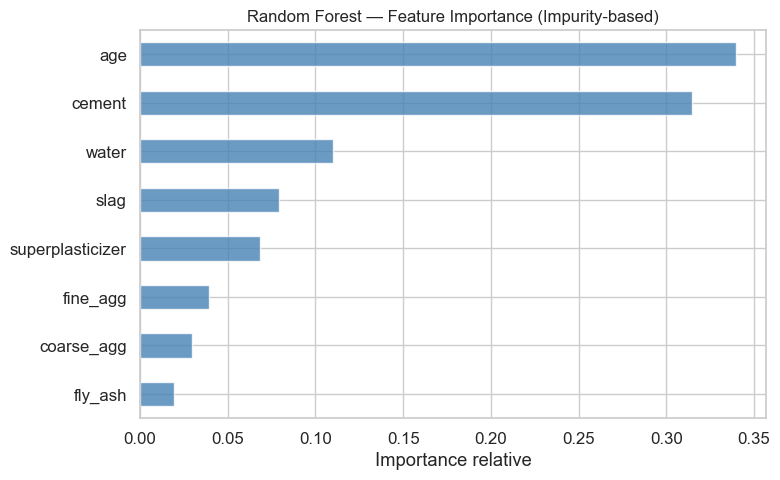


Meilleurs hyperparamètres trouvés (exemple fold complet) :
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}


In [9]:
# Feature Importance — entraîner sur tout le dataset pour visualiser
search_rf.fit(X, y)
best_rf = search_rf.best_estimator_.named_steps['model']

fi_rf = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
fi_rf.plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('Random Forest — Feature Importance (Impurity-based)', fontsize=12)
plt.xlabel('Importance relative')
plt.tight_layout()
plt.show()

print('\nMeilleurs hyperparamètres trouvés (exemple fold complet) :')
print(search_rf.best_params_)

---
## 5. Modèle 3 — Gradient Boosting Regressor

In [10]:
# --- PIPELINE GRADIENT BOOSTING ---
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),   # pas nécessaire pour GB (arbres), mais cohérence du Pipeline
    ('model', GradientBoostingRegressor(random_state=42))
])

param_grid_gb = {
    'model__n_estimators':  [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth':     [3, 4, 5],
    'model__subsample':     [0.8, 1.0]
}
# Total : 3 × 4 × 3 × 2 = 72 combinaisons × 5 folds inner × 5 folds outer = 1 800 entraînements
# subsample < 1.0 → Stochastic Gradient Boosting : réduit la variance, améliore la généralisation

search_gb = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_grid_gb,
    cv=inner_cv,
    scoring=SCORING_INNER,
    refit=True,
    n_jobs=N_JOBS
)

print('Entraînement Gradient Boosting en cours...')
t0 = time.time()

scores_gb = cross_val_score(
    estimator=search_gb,
    X=X, y=y,
    cv=outer_cv,
    scoring=SCORING_INNER,
    n_jobs=N_JOBS
)

elapsed = time.time() - t0
print(f'Terminé en {elapsed:.1f}s')

rmse_gb = compute_metrics(scores_gb, model_name='Gradient Boosting')

Entraînement Gradient Boosting en cours...
Terminé en 56.3s

=== Gradient Boosting ===
RMSE par fold : [4.219 4.244 3.786 4.608 4.183]
RMSE moyen    : 4.208 MPa  (±0.261)


In [11]:
r2_gb = cross_val_score(
    estimator=search_gb,
    X=X, y=y,
    cv=outer_cv,
    scoring='r2',
    n_jobs=N_JOBS
)
print(f'R² moyen GB : {r2_gb.mean():.3f} (±{r2_gb.std():.3f})')

R² moyen GB : 0.932 (±0.010)


---
## 6. Comparaison des 3 modèles

In [12]:
results = pd.DataFrame({
    'Modèle': ['Ridge', 'Random Forest', 'Gradient Boosting'],
    'RMSE moyen (MPa)': [
        rmse_ridge.mean(), rmse_rf.mean(), rmse_gb.mean()
    ],
    'RMSE std': [
        rmse_ridge.std(), rmse_rf.std(), rmse_gb.std()
    ],
    'R² moyen': [
        r2_ridge.mean(), r2_rf.mean(), r2_gb.mean()
    ],
    'R² std': [
        r2_ridge.std(), r2_rf.std(), r2_gb.std()
    ]
}).set_index('Modèle')

print('=== RÉSULTATS NESTED CV (5 folds outer) ===')
print(results.round(4))
print()
best_model = results['RMSE moyen (MPa)'].idxmin()
print(f'→ Meilleur modèle (RMSE le plus bas) : {best_model}')

=== RÉSULTATS NESTED CV (5 folds outer) ===
                   RMSE moyen (MPa)  RMSE std  R² moyen  R² std
Modèle                                                         
Ridge                       10.3852    0.4487    0.5898  0.0312
Random Forest                4.9354    0.3181    0.9069  0.0138
Gradient Boosting            4.2082    0.2607    0.9322  0.0100

→ Meilleur modèle (RMSE le plus bas) : Gradient Boosting


### Visualisation des scores par fold

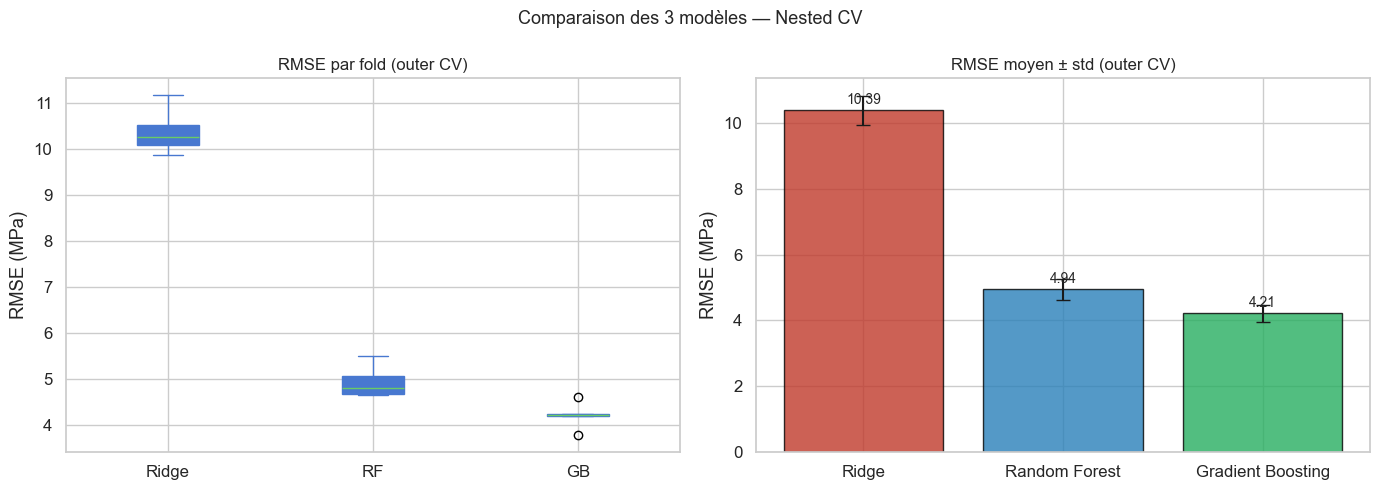

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot RMSE
rmse_data = pd.DataFrame({
    'Ridge': rmse_ridge,
    'Random Forest': rmse_rf,
    'Gradient Boosting': rmse_gb
})

rmse_data.plot(kind='box', ax=axes[0], patch_artist=True)
axes[0].set_title('RMSE par fold (outer CV)', fontsize=12)
axes[0].set_ylabel('RMSE (MPa)')
axes[0].set_xticklabels(['Ridge', 'RF', 'GB'])

# Barplot RMSE moyen avec barre d'erreur
models = ['Ridge', 'Random Forest', 'Gradient Boosting']
means = [rmse_ridge.mean(), rmse_rf.mean(), rmse_gb.mean()]
stds  = [rmse_ridge.std(), rmse_rf.std(), rmse_gb.std()]
colors = ['#c0392b', '#2980b9', '#27ae60']

bars = axes[1].bar(models, means, yerr=stds, capsize=5,
                   color=colors, alpha=0.8, edgecolor='black')
axes[1].set_title('RMSE moyen ± std (outer CV)', fontsize=12)
axes[1].set_ylabel('RMSE (MPa)')
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Comparaison des 3 modèles — Nested CV', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Modèle Final — Réentraînement sur tout le dataset

In [15]:
final_search = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_grid_gb,
    cv=inner_cv,
    scoring=SCORING_INNER,
    refit=True,
    n_jobs=N_JOBS
)
final_search.fit(X, y)

print('Meilleurs hyperparamètres (modèle final) :')
print(final_search.best_params_)
print(f'\nRMSE inner CV (approx, légèrement optimiste) : {np.sqrt(-final_search.best_score_):.3f} MPa')
print(f'RMSE outer CV (estimation honnête)          : {rmse_gb.mean():.3f} ± {rmse_gb.std():.3f} MPa')

Meilleurs hyperparamètres (modèle final) :
{'model__learning_rate': 0.2, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__subsample': 1.0}

RMSE inner CV (approx, légèrement optimiste) : 3.962 MPa
RMSE outer CV (estimation honnête)          : 4.208 ± 0.261 MPa


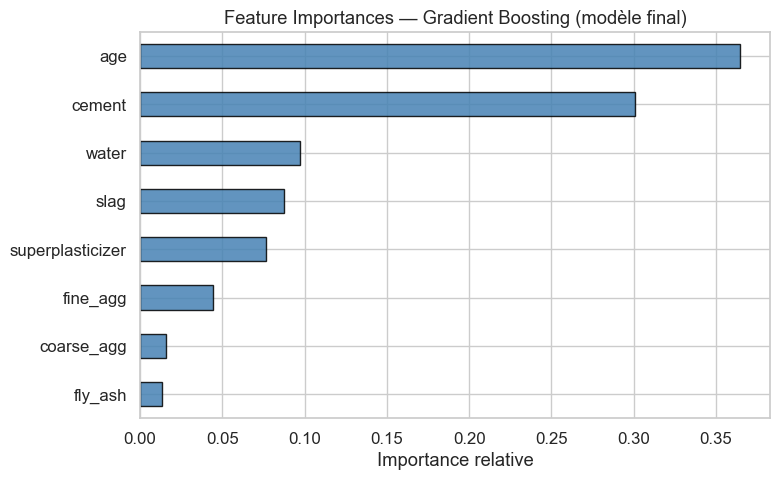


Classement des features par importance :
age                0.3650
cement             0.3010
water              0.0970
slag               0.0880
superplasticizer   0.0770
fine_agg           0.0440
coarse_agg         0.0160
fly_ash            0.0130


In [16]:
# Feature Importances du modèle final
best_model_final = final_search.best_estimator_.named_steps['model']

importances = pd.Series(best_model_final.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

importances.plot(kind='barh', figsize=(8, 5), color='steelblue', edgecolor='black', alpha=0.85)
plt.xlabel('Importance relative')
plt.title('Feature Importances — Gradient Boosting (modèle final)')
plt.tight_layout()
plt.show()

print('\nClassement des features par importance :')
print(importances.sort_values(ascending=False).round(3).to_string())

In [17]:
# Entraîner chaque search sur tout le dataset pour voir les meilleurs HPs globaux
# (ceci est pour l'inspection, pas pour l'évaluation — déjà faite via outer CV)

for name, search in [('Ridge', search_ridge), ('Random Forest', search_rf), ('Gradient Boosting', search_gb)]:
    search.fit(X, y)
    print(f'{name} — Meilleurs HPs : {search.best_params_}')
    print(f'   → Score inner CV (neg_MSE) : {search.best_score_:.4f}')
    print(f'   → RMSE inner CV (approx)   : {np.sqrt(-search.best_score_):.3f} MPa')
    print()

Ridge — Meilleurs HPs : {'model__alpha': 1}
   → Score inner CV (neg_MSE) : -107.3684
   → RMSE inner CV (approx)   : 10.362 MPa

Random Forest — Meilleurs HPs : {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
   → Score inner CV (neg_MSE) : -23.5985
   → RMSE inner CV (approx)   : 4.858 MPa

Gradient Boosting — Meilleurs HPs : {'model__learning_rate': 0.2, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__subsample': 1.0}
   → Score inner CV (neg_MSE) : -15.6952
   → RMSE inner CV (approx)   : 3.962 MPa



---
## 8. Specialized Focus — Interprétabilité dans le domaine de la Construction

Focus sur **pourquoi l'interprétabilité est critique en génie civil** et comment chaque modèle y répond.

- **Ridge** → coefficients standardisés, pleinement explicables
- **RF / GB** → Feature Importance (impurity-based)
- **Neural Networks** → exclus (boîte noire, inacceptable pour la sécurité structurelle)

### 8.1 / 8.2 — Prédiction vs Explication

| Learner | Interprétabilité | Raison |
|---|---|---|
| Ridge | ✅ Haute | Coefficients directement lisibles |
| Random Forest | ⚠️ Partielle | Feature Importance (pas de direction) |
| Gradient Boosting | ⚠️ Partielle | Feature Importance (pas de direction) |
| Neural Networks | ❌ Faible | Boîte noire, exclu du projet |

### 8.3 Coefficients Ridge

### 8.3 Coefficients Ridge

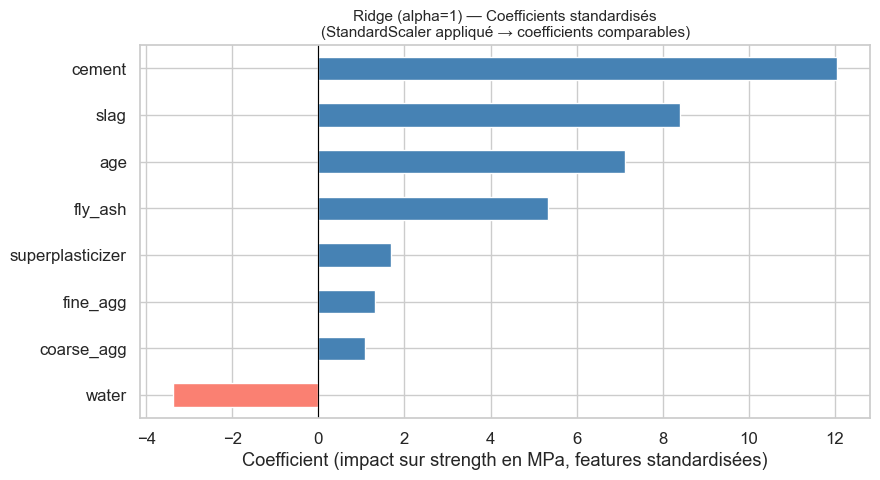

Coefficients Ridge (features standardisées) :
water              -3.3690
coarse_agg          1.0960
fine_agg            1.3170
superplasticizer    1.6780
fly_ash             5.3460
age                 7.1310
slag                8.3950
cement             12.0520

Intercept (résistance moyenne de base) : 35.25 MPa


In [18]:
# Coefficients Ridge — le modèle le plus interprétable
# Entraîner Ridge sur tout le dataset avec le meilleur alpha
search_ridge.fit(X, y)
best_alpha = search_ridge.best_params_['model__alpha']

# Extraire les coefficients standardisés
scaler_ridge = search_ridge.best_estimator_.named_steps['scaler']
model_ridge = search_ridge.best_estimator_.named_steps['model']

coefficients = pd.Series(model_ridge.coef_, index=X.columns).sort_values()

plt.figure(figsize=(9, 5))
colors = ['salmon' if c < 0 else 'steelblue' for c in coefficients]
coefficients.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Ridge (alpha={best_alpha}) — Coefficients standardisés\n(StandardScaler appliqué → coefficients comparables)', fontsize=11)
plt.xlabel('Coefficient (impact sur strength en MPa, features standardisées)')
plt.tight_layout()
plt.show()

print('Coefficients Ridge (features standardisées) :')
print(coefficients.round(3).to_string())
print(f'\nIntercept (résistance moyenne de base) : {model_ridge.intercept_:.2f} MPa')

**Interprétation :** cement (+12.05) et slag (+8.40) sont les features les plus impactantes positivement. water (-3.37) est la seule à impact négatif.

### 8.4 Feature Importance — RF vs GB

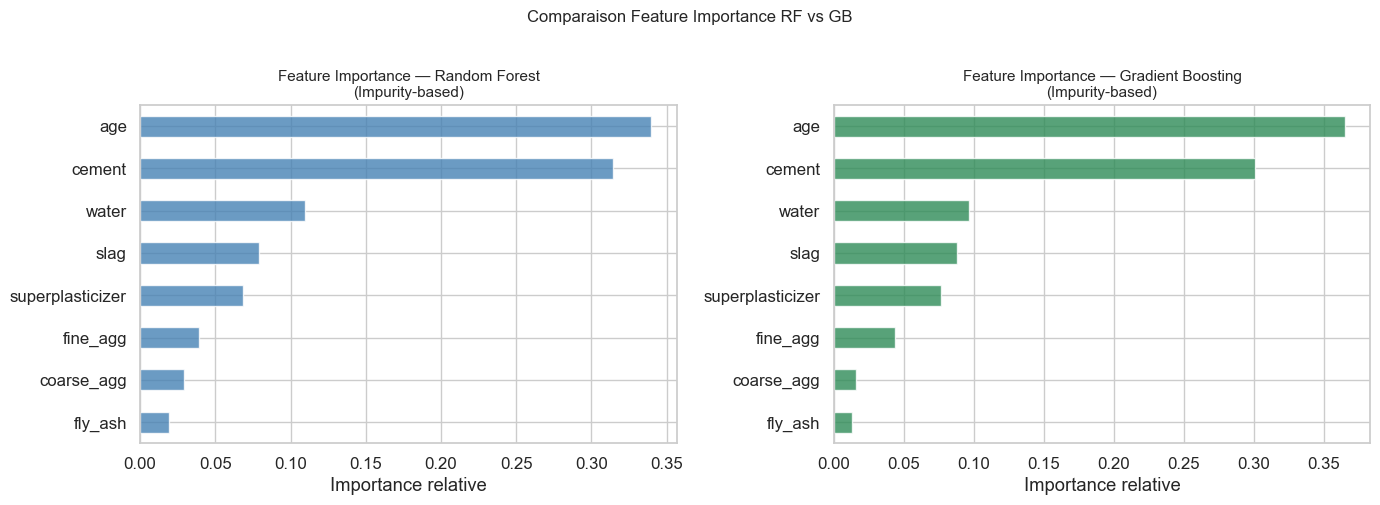


Classement des features par importance (RF) :
age                0.3400
cement             0.3150
water              0.1100
slag               0.0790
superplasticizer   0.0690
fine_agg           0.0390
coarse_agg         0.0290
fly_ash            0.0190

Classement des features par importance (GB) :
age                0.3650
cement             0.3010
water              0.0970
slag               0.0880
superplasticizer   0.0770
fine_agg           0.0440
coarse_agg         0.0160
fly_ash            0.0130


In [19]:
# Feature Importance comparée RF vs GB
search_gb.fit(X, y)
best_gb = search_gb.best_estimator_.named_steps['model']
best_rf = search_rf.best_estimator_.named_steps['model']

fi_rf_vals = pd.Series(best_rf.feature_importances_, index=X.columns)
fi_gb_vals = pd.Series(best_gb.feature_importances_, index=X.columns)

fi_compare = pd.DataFrame({
    'Random Forest': fi_rf_vals,
    'Gradient Boosting': fi_gb_vals
}).sort_values('Random Forest', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fi_compare['Random Forest'].plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Feature Importance — Random Forest\n(Impurity-based)', fontsize=11)
axes[0].set_xlabel('Importance relative')

fi_compare['Gradient Boosting'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen', alpha=0.8)
axes[1].set_title('Feature Importance — Gradient Boosting\n(Impurity-based)', fontsize=11)
axes[1].set_xlabel('Importance relative')

plt.suptitle('Comparaison Feature Importance RF vs GB', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('\nClassement des features par importance (RF) :')
print(fi_rf_vals.sort_values(ascending=False).round(3).to_string())
print('\nClassement des features par importance (GB) :')
print(fi_gb_vals.sort_values(ascending=False).round(3).to_string())

**Note :** age et cement dominent (~64% combined). Cohérent avec la physique du béton (hydratation + dosage).

In [21]:
print('=== RÉSULTATS QUANTITATIFS NESTED CV (5-fold outer) ===')
print()
print(results.round(4).to_string())
print()
print('RMSE par fold — tous les modèles :')
all_folds = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'Ridge RMSE':   np.round(rmse_ridge, 3),
    'RF RMSE':      np.round(rmse_rf, 3),
    'GB RMSE':      np.round(rmse_gb, 3)
})
print(all_folds.to_string(index=False))

=== RÉSULTATS QUANTITATIFS NESTED CV (5-fold outer) ===

                   RMSE moyen (MPa)  RMSE std  R² moyen  R² std
Modèle                                                         
Ridge                       10.3852    0.4487    0.5898  0.0312
Random Forest                4.9354    0.3181    0.9069  0.0138
Gradient Boosting            4.2082    0.2607    0.9322  0.0100

RMSE par fold — tous les modèles :
  Fold  Ridge RMSE  RF RMSE  GB RMSE
Fold 1      9.8740   4.8080   4.2190
Fold 2     10.5240   5.0660   4.2440
Fold 3     11.1740   4.6420   3.7860
Fold 4     10.0860   5.4950   4.6080
Fold 5     10.2670   4.6660   4.1830


---
## 10. Résumé final et justifications méthodologiques

### Ce qu'on a fait

| Étape | Détail |
|---|---|
| Pipeline sklearn | StandardScaler + Modèle encapsulé → zéro data leakage |
| Inner loop | GridSearchCV 5-fold → tuning hyperparamètres |
| Outer loop | cross_val_score 5-fold → estimation GE non biaisée |
| Modèles | Ridge (baseline linéaire), RF (bagging), GB (boosting) |
| Métriques | RMSE (MPa) + R² — toutes calculées sur les folds outer (non biaisées) |

### Justifications méthodologiques

**Pourquoi une nested CV et pas une simple CV ?**  
→ Sans nested CV, les hyperparamètres sont tunés sur les mêmes données qui servent à l'évaluation. On sélectionne le minimum d'une distribution bruitée → biais optimiste (synthèse `10_Nested_Resampling`). La nested CV sépare physiquement le tuning de l'évaluation.

**Comment le Pipeline évite le data leakage ?**  
→ Le StandardScaler est fitté uniquement sur le train de chaque fold, jamais sur le test. Sans Pipeline, si on scale avant CV, les statistiques (moyenne, std) sont calculées sur toutes les données, incluant les folds de test → fuite d'information.

**Pourquoi StandardScaler pour des arbres ?**  
→ Techniquement pas nécessaire pour RF et GB (les arbres font des coupures, pas des produits scalaires). On le garde pour la cohérence du Pipeline et parce que ça ne nuit pas aux arbres. Pour Ridge en revanche, c'est indispensable.

**Pourquoi ces hyperparamètres précisément ?**  
→ Grilles compactes (≤ 72 combinaisons) pour respecter la contrainte de temps d'exécution. Les valeurs sont basées sur les règles empiriques du cours : alpha Ridge sur un ordre de grandeur log, max_depth GB petit (3-5) pour garder des apprenants faibles.

**Comment interpréter le RMSE ?**  
→ Un RMSE de X MPa signifie qu'en moyenne, on se trompe de X MPa sur la résistance prédite. Avec une target qui varie de 2 à 82 MPa (range = 80 MPa), un RMSE de 5 MPa = erreur relative d'environ 6%. C'est acceptable pour de la prédiction de béton.

**Le meilleur modèle issu de la CV est-il le modèle final ?**  
→ Non — les modèles issus des folds CV sont des modèles **intermédiaires**, à jeter après l'évaluation. Le modèle final (§7) est entraîné sur TOUTES les données avec le meilleur λ* identifié. (synthèse `4_Evaluation`, section K-Fold CV)